In [1]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
import gc
from pathlib import Path
from define_data_and_variables import pt_config, data, hash_configs, version
import json


In [2]:
base_dir = Path.cwd()
print(base_dir)

base_path = base_dir / ".." / ".." / ".." / ".." / "data"
data_name = rf"$A_{{{data["dn"][:3]}}}$"
true_sample = np.load(base_path / data["dn"] / version / "true_sample.npy")
int_version = int(version)
true_ages = np.hstack((data["th"], data["th"] - np.cumsum(true_sample) * data["dc"]))
c14_label = r"$^{230}$Th" if "d18o" in data["dn"] else r"$^{14}$C"
measure = "mm" if "d18o" in data["dn"] else "cm"


c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_PT_normal_c14_d18o


In [3]:
base_dir = Path.cwd()
# adam_config_ee = adam_config
# adam_config_ee["mi"] = 10000
# adam_hash_ee = hash_configs(adam_config_ee, data)

# adam_dir = base_dir / f"output/{data["dn"]}/{adam_hash}"
# adam_dir_ee = base_dir / f"output/{data['dn']}/{adam_hash_ee}"

# starting_points = np.load(adam_dir / "adam_samples.npy")
# energies = np.load(adam_dir / "adam_energies.npy")

# indices = np.argsort(energies)
# sp = starting_points[indices][:pt_config["nt"]]
sp_dir = base_dir / f"output/{data['dn']}/{version}"
np.random.seed(pt_config['hmcc']['sd'])
sp = np.random.lognormal(mean = data["pm"], sigma = data["ps"], size = (pt_config["nt"], data["N"]))
pt_config["hmcc"]["sp"] = np.ascontiguousarray(sp)

pt_hash = hash_configs(pt_config, data)
output_dir = sp_dir / f"{pt_hash}"

hmc_config = pt_config["hmcc"]

In [4]:
colors = plt.cm.viridis(np.linspace(0, 1, pt_config["nt"]))

[[ 0  0  0 ...  3  3  3]
 [11 11  9 ...  0  0  4]
 [ 2  9 11 ...  2  4  0]
 ...
 [19 10 10 ... 16 12 12]
 [ 6  6  6 ... 18  7  7]
 [15 15 15 ...  7 18 18]]
(20, 90001)
[[ 0  0  0 ...  3  3  3]
 [11 11  9 ...  0  0  4]
 [ 2  9 11 ...  2  4  0]
 ...
 [19 10 10 ... 16 12 12]
 [ 6  6  6 ... 18  7  7]
 [15 15 15 ...  7 18 18]]


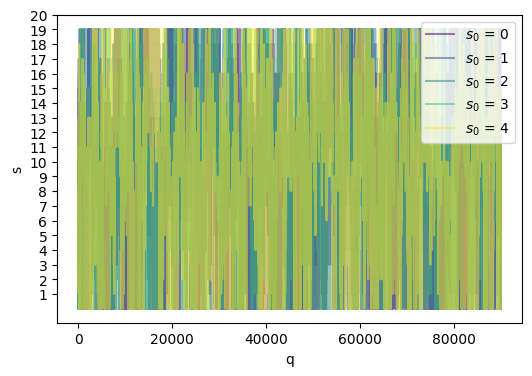

In [ ]:
import matplotlib as mpl
cutout = 10000
num_starts = 5
temp_indices = np.load(output_dir / "temp_indices.npy", mmap_mode='r')[:, cutout:]
norm = mpl.colors.Normalize(vmin=min(pt_config['bs'][0:num_starts]), vmax=max(pt_config['bs'][0:num_starts]))
cmap = plt.cm.viridis
# temp_indices = (temp_indices == 19).argmax(axis=0)
print(temp_indices)
print(np.shape(temp_indices))
plt.figure(figsize=(6, 4))
xmin = 0
xmax = len(temp_indices[0, :])
# for i in range(len(temp_indices)):
plt.hlines(np.linspace(0, pt_config["nt"] - 1, pt_config["nt"]), linestyle = '--', color = "grey", linewidth = 0.1,  xmin = xmin, xmax = xmax)
for i in range(0, num_starts):
    temp_indices_i = (temp_indices == i).argmax(axis=0)
    plt.plot(np.arange(xmin, xmax, 1), temp_indices_i[xmin:xmax], label = r"$s_0$" + f" = {i}", color = cmap(norm(pt_config['bs'][i])), alpha = 0.5)  
print(temp_indices)
plt.yticks(np.linspace(1, pt_config["nt"], pt_config["nt"]))
plt.ylabel("s")
plt.xlabel("q")
plt.legend(loc = "upper right")
plt.savefig(f"{output_dir}/index_evolution.jpg")
plt.show()


In [6]:
backwards = False
round_trip = 0
num_temps = len(temp_indices)
num_samples = len(temp_indices[0, cutout:])
for chain in range(num_temps):
    for col in range(num_samples):
        if temp_indices[0, col] == chain and backwards:
            round_trip+=1
            backwards = False
        if temp_indices[-1, col] == chain:
            backwards = True
print(round_trip / (num_samples * num_temps))


0.00043749453131835853


In [7]:
samples = np.load(output_dir / "samples.npy", mmap_mode='r')[:, cutout:, :]

In [8]:
import arviz as az
# for i in range(len(samples[-1,0,:])):    
#     print(f"ess x[{i}]: {az.ess(samples[-1, :, i], method="bulk")}")

# print(az.summary(samples))
ess_array = np.array([az.ess(samples[-1, :, i], method = "bulk") for i in range(len(samples[-1, 0, :]))])
print(ess_array)
min_ess = np.min(ess_array)
print(min_ess)

[50192.21917786 82506.23162859 63635.81115176 31203.59710923
 45180.41258519 41537.19470659 35105.54240145 29814.02211175
 25071.83362602  4561.22189593  2945.04944222  8934.68196278
  2500.50283513 17772.86813699 33995.49400054 47494.24575899
 45694.15062265 26698.19332614  2541.70984243  3001.16946999
  3111.07117176 20997.61026746  6570.76586692  2544.41537498
 20923.16362631 23367.1930943  25399.3828648  13386.61552084
 14124.02720875 31422.18442633 38698.1148735  38240.73268699
 35521.2531729  34997.10996951 54964.54006528 92090.52268133
 61513.18724917 24028.5838353  27051.60614289 21205.92075964
 14731.13545794 13325.36739506  1600.45479145  1531.06189604
  4364.98723575 51484.83677838 61460.2284075  65013.41017304
 55605.04937714 19150.07044164]
1531.061896043217


In [9]:
energy_values = np.load(output_dir / "energy.npy", mmap_mode='r')[:, cutout:]
d18o_energy_values = np.load(output_dir / "d18o_energy.npy", mmap_mode='r')[:, cutout:]
min_energies = [np.min(energy_values, axis = 1)[i] for i in range(pt_config["nt"])]
min_energy_samples = [samples[i, np.argmin(energy_values, axis = 1)[i], :] for i in range(pt_config["nt"])]
closest_to_true_samples = [samples[i, np.argmin(np.linalg.norm(samples[i, :, :] - true_sample, axis = 1)), :] for i in range(pt_config["nt"])]
print(min_energies)

[np.float64(79.37335265313457), np.float64(81.83317238274236), np.float64(83.93716552779749), np.float64(86.91092151743275), np.float64(88.40417623989127), np.float64(90.29200222906573), np.float64(92.90433202169524), np.float64(98.6846993594505), np.float64(102.26437460150385), np.float64(107.44032407898806), np.float64(111.24438944234501), np.float64(120.00244731115794), np.float64(126.03022549921921), np.float64(135.9909919567429), np.float64(142.73547431063193), np.float64(156.24302094436752), np.float64(168.60177229326206), np.float64(185.3805231677677), np.float64(203.67680357862815), np.float64(228.33049801491848)]


In [10]:
for i in range(0, pt_config["nt"] - 1):
    temp_indices_i = (temp_indices == i).argmax(axis=0)
    print(np.min(temp_indices_i))
    rej_indices = np.where((np.diff(temp_indices_i) == 0) & (temp_indices_i[:-1] != pt_config["nt"] - 1))[0]
    print(rej_indices)
    rej = 0
    for j in range(len(rej_indices)):
        rej+= 1 - np.min([1, np.exp((pt_config["bs"][temp_indices_i[rej_indices][j] + 1] - pt_config["bs"][temp_indices_i[rej_indices][j]]) * (d18o_energy_values[temp_indices_i[rej_indices][j] + 1, rej_indices][j] - d18o_energy_values[temp_indices_i[rej_indices][j], rej_indices][j]))])
    print(rej / pt_config["hmcc"]["ns"])

0
[    0     1     2 ... 89991 89995 89998]
0.17883513320415087
0
[    2     6    10 ... 89991 89998 89999]
0.17807026154037806
0
[    1     2     5 ... 89994 89995 89999]
0.1777357705014884
0
[    1     2     3 ... 89997 89998 89999]
0.18099842761803187


MemoryError: Unable to allocate 1.72 MiB for an array with shape (20, 90001) and data type bool

In [ ]:
# print(energy_values)
print(d18o_energy_values)

[[483.60788419 555.66953661 571.27919698 ... 512.37481618 495.53127465
  461.77309959]
 [522.7139315  480.58910061 499.81753452 ... 521.5328956  441.8550176
  440.69539281]
 [392.89893302 431.05916453 436.22167242 ... 424.97593415 467.80480409
  540.08675931]
 ...
 [201.6017081  184.88787595 192.20612943 ... 190.36302965 191.67166946
  183.38961412]
 [169.73732606 184.16471162 181.42332865 ... 174.38585549 165.65967089
  170.21683239]
 [176.7197358  176.12005304 164.66956125 ... 170.64792017 173.29457976
  166.0657102 ]]


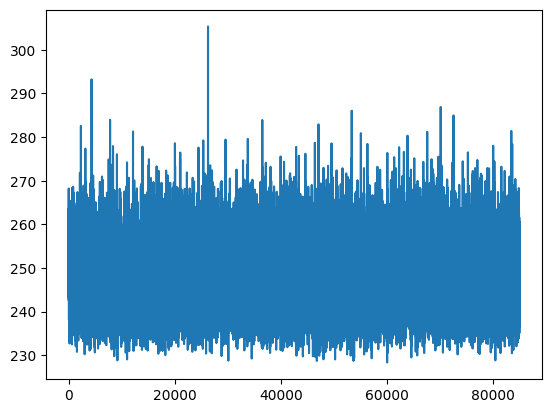

In [ ]:
plt.figure()
chain = -1
plt.plot(energy_values[chain] - (pt_config["bs"][chain] - 1) * d18o_energy_values[chain])
plt.show()

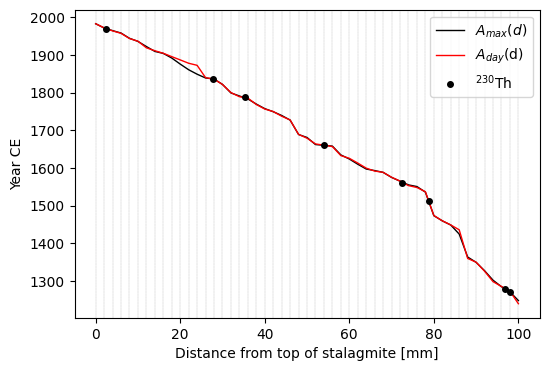

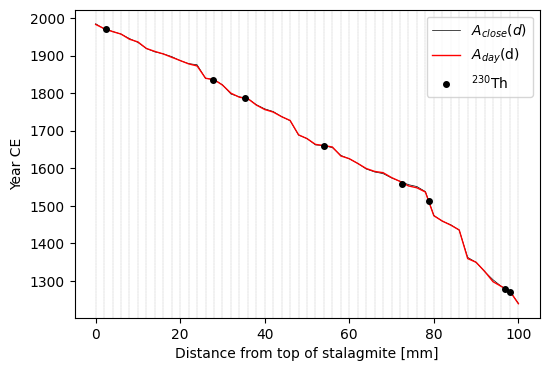

In [ ]:
chain = -1
fig, ax = plt.subplots(figsize=(6, 4))
plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([0], np.cumsum(min_energy_samples[chain]))), color = "black", alpha = 1, linewidth = 1, label = r"$A_{max}(d)$")
ax.plot(data["cs"], true_ages, color = "red", linewidth=1, alpha = 1, label = data_name + "(d)")
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
plt.legend()
plt.savefig(f"{output_dir}/max_prob_sol.jpg")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(closest_to_true_samples[chain]))), color = "black", alpha = 1, linewidth = 0.5, label = r"$A_{close}(d)$")
ax.plot(data["cs"], true_ages, color = "red", linewidth=1, alpha = 1, label = data_name + "(d)")
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
plt.legend()
plt.savefig(f"{output_dir}/close_prob_sol.jpg")
plt.show()

In [ ]:
index = 12
interesting_depth = index * data["dc"]

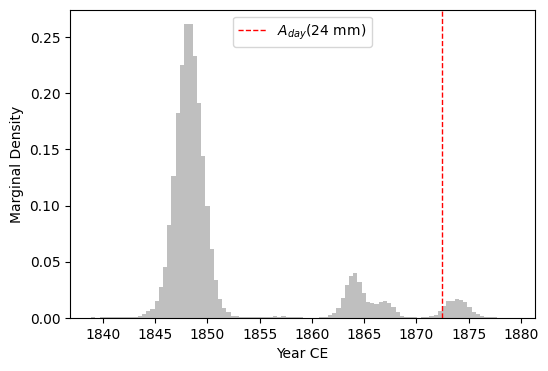

In [ ]:
CV_values = data["th"] - data["dc"] * np.sum(samples[-1, :, :index], axis = 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(CV_values, bins = 100, color = "grey", alpha = 0.5, density = True)
ax.set_xlabel("Year CE")
ax.set_ylabel("Marginal Density")
ax.axvline(x=true_ages[index], color="red", linestyle='--', linewidth = 1, label = data_name + f"({int(interesting_depth)} " + measure + ")")
plt.legend()
plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

In [ ]:
from matplotlib import colors

X = samples[-1, :, :].T
D, N = X.shape

# Depth grid (0:2:2*D)'

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

# age_mean = np.mean(age, axis = 1)
norm_age = age #- true_age[:, None]

# Time bins
dt = 1
t_edges = np.arange(np.min(data["d18ort"]), np.max(data["d18ort"]) + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = 0.1
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for i in range(Z):
    C[i, :], _ = np.histogram(A[i, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    if i ==index: 
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 1, label = f"d = {int(interesting_depth)} " + measure)
    else:
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
ax.plot(data["cs"], true_ages, color = "red", linewidth=0.5, alpha = 1, label = data_name + "(d)")
im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    # vmin=0,
    # vmax=0.01 * N,
    norm=colors.LogNorm(1e-4, 1)
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Marginal Density")
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
plt.savefig(f"{output_dir}/resampled_no_mean.jpg")
plt.show()

del A, C
gc.collect()


MemoryError: Unable to allocate 649. MiB for an array with shape (85000, 1001) and data type float64

c:\Users\hanna\Desktop\PhD\Bacon\bacon_venv\Lib\site-packages\numpy\lib\_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


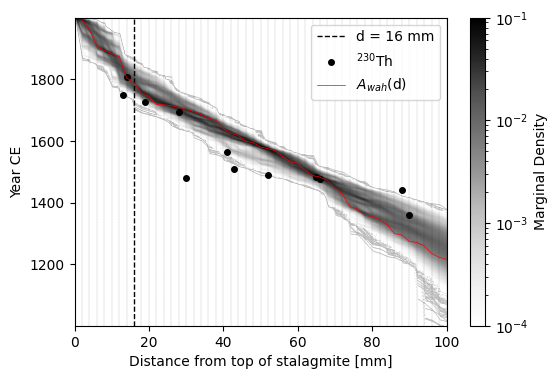

16830

In [ ]:
from matplotlib import colors

X = samples[0, :, :].T
D, N = X.shape

# Depth grid (0:2:2*D)'

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

# age_mean = np.mean(age, axis = 1)
norm_age = age #- true_age[:, None]

# Time bins
dt = 1
t_edges = np.arange(np.min(data["d18ort"]), np.max(data["d18ort"]) + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = 0.1
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for i in range(Z):
    C[i, :], _ = np.histogram(A[i, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    if i ==index: 
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 1, label = f"d = {int(interesting_depth)} " + measure)
    else:
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
ax.plot(data["cs"], true_ages, color = "red", linewidth=0.5, alpha = 1, label = data_name + "(d)")
im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    # vmin=0,
    # vmax=0.01 * N,
    norm=colors.LogNorm(1e-4, 1e-1)
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Marginal Density")
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
plt.savefig(f"{output_dir}/sampled_no_mean.jpg")
plt.show()

del A, C
gc.collect()
